# 09 - Fraud Path: Adding a Temporal Clustering Check

The investigator tool built in notebook 08 has one gate: are there enough
genuinely close semantic matches (cosine similarity >= 0.85, 3+ of them) to
call something a "finding"? That's the right gate for the quality
workflow -- "does this complaint match a known pattern" -- but it's too weak
for the fraud workflow. Notebook 07 already showed that semantic near-
duplicate clusters are mostly template reuse spread over months/years, not
coordination. A real fraud signal needs *both* semantic similarity *and*
a suspicious temporal pattern (a spike, not a uniform spread).

This notebook adds that second gate -- `temporal_suspicion_score()` -- and
calibrates it against the 218 near-duplicate clusters notebook 07 already
found and read through by hand, every one of which it concluded was
independent template reuse, not coordination. Those clusters are reused here
as a known-innocent calibration set: whatever thresholds we pick, they
should not flag most of these 218 as suspicious, since we already have a
documented, human-read reason to believe they aren't.

The semantic gate itself (`investigate_case()` in `src/retrieval.py`,
validated in notebook 08) is left untouched. The temporal check is added as
a separate function, `evaluate_fraud_signal()`, that calls `investigate_case()`
and layers the temporal gate on top -- keeping the quality workflow (semantic
only) and fraud workflow (semantic + temporal) as two distinct, composable
pieces rather than overloading one function with both.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pickle

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

from src.embeddings import load_model
from src.retrieval import build_faiss_index, investigate_case

model = load_model()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## Reconstruct notebook 07's 218 clusters

Notebook 08 already cached the same population notebook 07 used (the 15k
slice filtered to non-empty narratives, 6,150 rows) as `full_complaints.parquet`
and `full_embeddings.pkl` -- load those instead of re-embedding, then rerun
the exact same near-duplicate clustering notebook 07 used (threshold 0.85,
connected components on the similarity graph) to get the same 218 clusters
back.

In [2]:
THRESHOLD = 0.85

df_full = pd.read_parquet("../data/processed/full_complaints.parquet")
with open("../data/processed/full_embeddings.pkl", "rb") as f:
    embeddings_full = pickle.load(f)

print(f"Full population: {len(df_full):,} complaints")


Full population: 6,150 complaints


In [3]:
sim_matrix = cosine_similarity(embeddings_full)
np.fill_diagonal(sim_matrix, -1)

G_dup = nx.Graph()
G_dup.add_nodes_from(df_full.index)

rows, cols = np.where(sim_matrix >= THRESHOLD)
for r, c in zip(rows, cols):
    if r < c:
        G_dup.add_edge(r, c, weight=sim_matrix[r, c])

components = [c for c in nx.connected_components(G_dup) if len(c) > 1]
components = sorted(components, key=len, reverse=True)

print(f"Duplicate clusters found (size > 1): {len(components)}")
print(f"Cluster sizes (top 10): {[len(c) for c in components[:10]]}")


Duplicate clusters found (size > 1): 218
Cluster sizes (top 10): [353, 82, 66, 61, 36, 33, 28, 23, 22, 21]


## `temporal_suspicion_score()`

Two signals, both computed from the filing dates of a cluster:

- **IQR-to-range ratio**: the interquartile range of dates divided by the
  total date range. If dates are spread uniformly, the middle 50% of points
  should occupy roughly half the range (ratio near 0.5). If dates spike
  together, the middle 50% collapses into a tiny slice of the range (ratio
  near 0).
- **KS test against uniform**: normalize dates to [0, 1] across the cluster's
  range and run `scipy.stats.kstest` against a uniform distribution. A small
  p-value means the dates are *not* what uniform random spread looks like --
  i.e., they're clustered somewhere rather than spread evenly.

Returns `None` if there are fewer than 3 dates -- not enough points for
either statistic to mean anything.

In [4]:
def temporal_suspicion_score(dates):
    dates = pd.to_datetime(pd.Series(dates)).sort_values().reset_index(drop=True)

    if len(dates) < 3:
        return None

    days = (dates - dates.min()).dt.days.astype(float).values
    total_range_days = float(days.max())

    if total_range_days == 0:
        # every complaint filed on the same day -- maximal spike, KS test
        # against a continuous uniform distribution isn't well-defined here.
        return {
            "iqr_days": 0.0,
            "iqr_to_range_ratio": 0.0,
            "ks_pvalue": 0.0,
            "total_range_days": 0.0,
        }

    q75, q25 = np.percentile(days, [75, 25])
    iqr_days = float(q75 - q25)
    ratio = iqr_days / total_range_days

    normalized = days / total_range_days
    _, ks_pvalue = stats.kstest(normalized, "uniform")

    return {
        "iqr_days": iqr_days,
        "iqr_to_range_ratio": ratio,
        "ks_pvalue": float(ks_pvalue),
        "total_range_days": total_range_days,
    }


## Calibrate against the 218 known-innocent clusters

`IQR_RATIO_THRESHOLD = 0.2` and `KS_PVALUE_THRESHOLD = 0.05` were the
starting hypotheses going in -- unvalidated. Run `temporal_suspicion_score`
on every one of the 218 clusters and look at where the real distribution
sits relative to those numbers, the same way notebook 07 looked at the
actual similarity histogram before committing to 0.85 rather than picking it
blind.

In [5]:
IQR_RATIO_THRESHOLD = 0.2
KS_PVALUE_THRESHOLD = 0.05

calibration_rows = []
for i, cluster in enumerate(components):
    dates = df_full.loc[list(cluster), "Date received"]
    score = temporal_suspicion_score(dates)
    if score is None:
        continue
    score["cluster_id"] = i
    score["cluster_size"] = len(cluster)
    calibration_rows.append(score)

calibration_df = pd.DataFrame(calibration_rows)
print(f"Clusters scored: {len(calibration_df)} / {len(components)} (rest had < 3 dates)")
calibration_df.describe()


Clusters scored: 113 / 218 (rest had < 3 dates)


,iqr_days,iqr_to_range_ratio,ks_pvalue,total_range_days,cluster_id,cluster_size
count,113.000000,113.000000,1.130000e+02,113.000000,113.00000,113.000000
mean,132.542035,0.435552,3.797601e-01,329.761062,56.00000,11.743363
std,140.560612,0.181910,3.271786e-01,302.516478,32.76431,34.488813
min,1.000000,0.013636,4.542871e-40,2.000000,0.00000,3.000000
25%,34.500000,0.296296,7.407407e-02,106.000000,28.00000,3.000000
50%,91.500000,0.500000,2.766287e-01,221.000000,56.00000,5.000000
75%,179.500000,0.500000,7.445957e-01,482.000000,84.00000,9.000000
max,673.250000,0.938776,9.845679e-01,1249.000000,112.00000,353.000000


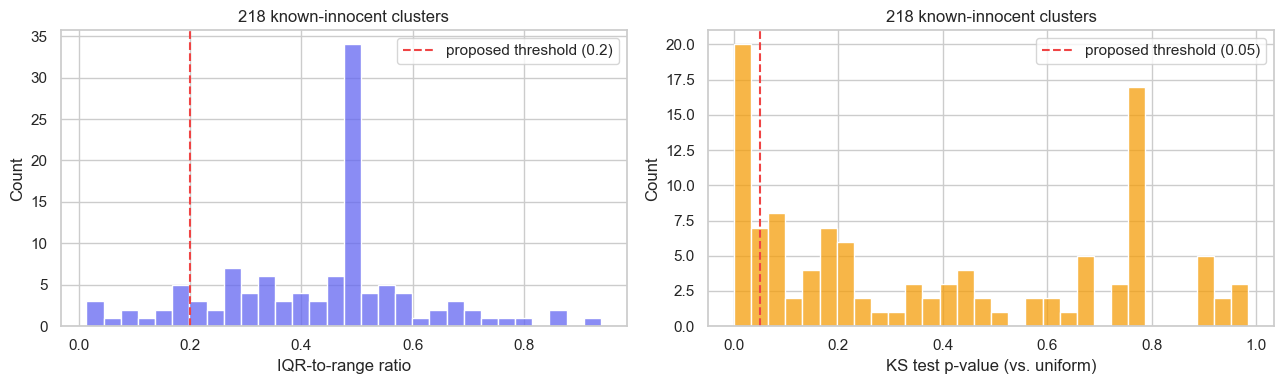

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(calibration_df["iqr_to_range_ratio"], bins=30, ax=axes[0], color="#6366f1")
axes[0].axvline(IQR_RATIO_THRESHOLD, color="#ef4444", linestyle="--", label=f"proposed threshold ({IQR_RATIO_THRESHOLD})")
axes[0].set_xlabel("IQR-to-range ratio")
axes[0].set_title("218 known-innocent clusters")
axes[0].legend()

sns.histplot(calibration_df["ks_pvalue"], bins=30, ax=axes[1], color="#f59e0b")
axes[1].axvline(KS_PVALUE_THRESHOLD, color="#ef4444", linestyle="--", label=f"proposed threshold ({KS_PVALUE_THRESHOLD})")
axes[1].set_xlabel("KS test p-value (vs. uniform)")
axes[1].set_title("218 known-innocent clusters")
axes[1].legend()

plt.tight_layout()
plt.show()


In [7]:
would_flag = calibration_df[
    (calibration_df["iqr_to_range_ratio"] < IQR_RATIO_THRESHOLD)
    & (calibration_df["ks_pvalue"] < KS_PVALUE_THRESHOLD)
]

print(f"Known-innocent clusters that would ALSO clear the temporal gate: "
      f"{len(would_flag)} / {len(calibration_df)} ({len(would_flag) / len(calibration_df) * 100:.1f}%)")
print()
print(would_flag[["cluster_id", "cluster_size", "iqr_to_range_ratio", "ks_pvalue", "total_range_days"]].to_string(index=False))


Known-innocent clusters that would ALSO clear the temporal gate: 12 / 113 (10.6%)

 cluster_id  cluster_size  iqr_to_range_ratio    ks_pvalue  total_range_days
          8            22            0.189146 2.447551e-02             949.0
         10            20            0.197628 1.056437e-03             506.0
         12            16            0.178694 2.874942e-06             291.0
         15            13            0.033866 1.200023e-08            1063.0
         25             9            0.078895 1.534571e-03             507.0
         26             9            0.072874 9.653494e-04             494.0
         38             7            0.087500 4.822731e-04              80.0
         42             6            0.043103 3.566344e-04             174.0
         45             6            0.191568 2.750606e-02             676.0
         48             5            0.013636 1.997093e-02             440.0
         56             5            0.113553 2.218037e-02            

In [8]:
candidate_thresholds = [
    (0.20, 0.05),
    (0.20, 0.01),
    (0.10, 0.05),
    (0.10, 0.01),
    (0.05, 0.01),
]

print(f"{'ratio<':>8} {'p<':>8} {'flagged':>10} {'rate':>8}")
for ratio_t, p_t in candidate_thresholds:
    flagged = calibration_df[
        (calibration_df["iqr_to_range_ratio"] < ratio_t)
        & (calibration_df["ks_pvalue"] < p_t)
    ]
    rate = len(flagged) / len(calibration_df) * 100
    print(f"{ratio_t:>8} {p_t:>8} {len(flagged):>10} {rate:>7.1f}%")


  ratio<       p<    flagged     rate
     0.2     0.05         12    10.6%
     0.2     0.01          7     6.2%
     0.1     0.05          6     5.3%
     0.1     0.01          5     4.4%
    0.05     0.01          2     1.8%


## A gap found by testing, not by calibration: scale-invariance

Both `temporal_suspicion_score` statistics are scale-invariant by
construction -- they normalize dates to the cluster's own `[0, 1]` range
before measuring shape. That means they only detect non-uniformity *within*
whatever range a cluster spans. They say nothing about whether the range
itself is short. Ten complaints spread perfectly evenly across an 8-day
window looks, to these two statistics, exactly like ten complaints spread
evenly across an 8-year window -- both get IQR-to-range ratio near 0.5 and a
KS p-value nowhere near significant, even though the 8-day case is exactly
the kind of tight-window coordination this gate exists to catch.

This is the gap the original "naive 60-day check" mentioned at the start of
this task actually covers, and the two new statistics don't replace it --
they're answering a different question (internal shape) than absolute range
answers (is the window short at all). Worth checking properly rather than
asserting it: does adding the absolute-range check back in, calibrated the
same way as everything else here, fix the gap without reintroducing a worse
false-positive problem?

In [9]:
ABS_RANGE_THRESHOLD_DAYS = 60

abs_range_flagged = calibration_df[calibration_df["total_range_days"] <= ABS_RANGE_THRESHOLD_DAYS]

print(f"Known-innocent clusters with total_range_days <= {ABS_RANGE_THRESHOLD_DAYS}: "
      f"{len(abs_range_flagged)} / {len(calibration_df)} ({len(abs_range_flagged) / len(calibration_df) * 100:.1f}%)")
print(f"Cluster sizes among those: {sorted(abs_range_flagged['cluster_size'].tolist())}")


Known-innocent clusters with total_range_days <= 60: 23 / 113 (20.4%)
Cluster sizes among those: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 6, 8, 10]


The absolute-range check alone is *worse* than the shape stats alone --
20.4% of known-innocent clusters would clear it, almost all of them tiny
(size 3-4). With only 3-4 independent filers scattered across a multi-year
dataset, landing within 60 days of each other by pure chance isn't actually
rare -- small samples make any "tight window" criterion noisy on its own.
So the original 60-day check wasn't wrong to want, it was incomplete on its
own, in the mirror-image way the shape stats are incomplete on their own.

The real question is whether requiring *all three* signals together --
low IQR-to-range ratio, low KS p-value, AND a short absolute range -- does
better than any one alone.

In [10]:
combined_flagged = calibration_df[
    (calibration_df["iqr_to_range_ratio"] < IQR_RATIO_THRESHOLD)
    & (calibration_df["ks_pvalue"] < KS_PVALUE_THRESHOLD)
    & (calibration_df["total_range_days"] <= ABS_RANGE_THRESHOLD_DAYS)
]

print(f"Known-innocent clusters clearing ALL THREE conditions: "
      f"{len(combined_flagged)} / {len(calibration_df)} ({len(combined_flagged) / len(calibration_df) * 100:.1f}%)")


Known-innocent clusters clearing ALL THREE conditions: 0 / 113 (0.0%)


## Is the parametric KS p-value even trustworthy here?

One more thing worth checking before trusting that 0% number: `scipy.stats.kstest`
assumes a *continuous* distribution, but these dates are day-resolution
integers, so small clusters (n=3-5, the bulk of the calibration set) get
exact ties. The calibration data already hinted at this -- some clusters
produced p-values like `1e-8` or `1e-40`, which is an extreme amount of
confidence to extract from 3-5 data points.

A permutation test sidesteps the continuity assumption directly: instead of
comparing the observed KS statistic to a theoretical continuous-uniform
reference, simulate the actual null process -- "if `n` complaints had landed
on uniformly random *days* (with the same day-granularity, ties included)
within this cluster's date range, what would the KS statistic look like?" --
many times, and see where the real cluster's statistic falls in that
simulated distribution. If the parametric p-values for small clusters are
artifacts of the continuity violation, this should disagree with them,
especially at the extreme end.

In [11]:
def ks_stat_uniform(values_2d):
    """Vectorized one-sample KS statistic vs. continuous uniform on [0, 1].
    values_2d: shape (n_samples, n_points), each row a sample."""
    n = values_2d.shape[1]
    sorted_vals = np.sort(values_2d, axis=1)
    i = np.arange(1, n + 1)
    d_plus = (i / n - sorted_vals).max(axis=1)
    d_minus = (sorted_vals - (i - 1) / n).max(axis=1)
    return np.maximum(d_plus, d_minus)


def ks_permutation_pvalue(dates, n_perm=2000, rng=None):
    rng = rng or np.random.default_rng(42)
    dates = pd.to_datetime(pd.Series(dates)).sort_values().reset_index(drop=True)
    n = len(dates)
    if n < 3:
        return None

    days = (dates - dates.min()).dt.days.astype(int).values
    total_range_days = int(days.max())
    if total_range_days == 0:
        return 0.0

    observed_stat = ks_stat_uniform((days / total_range_days)[None, :])[0]

    sim_days = rng.integers(0, total_range_days + 1, size=(n_perm, n))
    sim_stats = ks_stat_uniform(sim_days / total_range_days)

    return float(np.mean(sim_stats >= observed_stat))


Run it on every cluster in the calibration set and compare directly against
the parametric p-value already in `calibration_df`.

In [12]:
rng = np.random.default_rng(42)

perm_pvalues = []
for cluster_id in calibration_df["cluster_id"]:
    cluster = components[cluster_id]
    dates = df_full.loc[list(cluster), "Date received"]
    perm_pvalues.append(ks_permutation_pvalue(dates, n_perm=2000, rng=rng))

calibration_df["ks_pvalue_permutation"] = perm_pvalues

print(calibration_df[["cluster_id", "cluster_size", "ks_pvalue", "ks_pvalue_permutation"]]
      .sort_values("ks_pvalue")
      .head(15)
      .to_string(index=False))


 cluster_id  cluster_size    ks_pvalue  ks_pvalue_permutation
          0           353 4.542871e-40                 0.0000
          2            66 4.730900e-15                 0.0000
         15            13 1.200023e-08                 0.0000
         12            16 2.874942e-06                 0.0000
         18            10 6.225325e-05                 0.0000
         11            17 6.535864e-05                 0.0000
         42             6 3.566344e-04                 0.0000
         38             7 4.822731e-04                 0.0010
         26             9 9.653494e-04                 0.0015
         10            20 1.056437e-03                 0.0010
          9            21 1.333289e-03                 0.0015
         25             9 1.534571e-03                 0.0015
          6            28 1.574023e-03                 0.0015
          4            36 1.665902e-03                 0.0020
         37             7 5.898559e-03                 0.0045


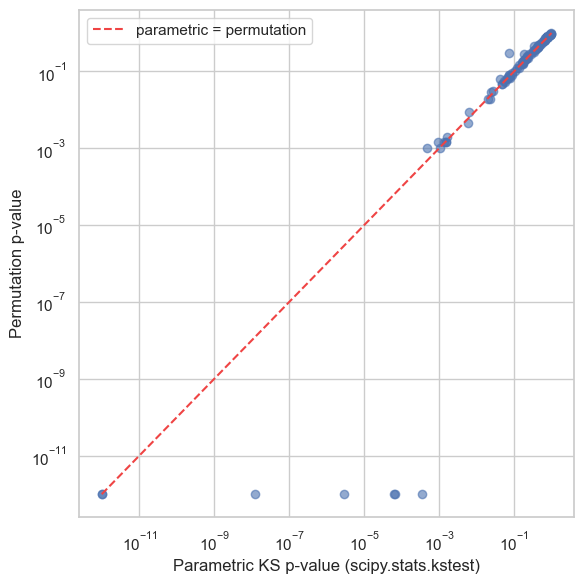

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    calibration_df["ks_pvalue"].clip(lower=1e-12),
    calibration_df["ks_pvalue_permutation"].clip(lower=1e-12),
    alpha=0.6,
)
ax.plot([1e-12, 1], [1e-12, 1], color="#ef4444", linestyle="--", label="parametric = permutation")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Parametric KS p-value (scipy.stats.kstest)")
ax.set_ylabel("Permutation p-value")
ax.legend()
plt.tight_layout()
plt.show()


## Does the 0% finding survive switching to the permutation p-value?

In [14]:
perm_flagged_alone = calibration_df[
    (calibration_df["iqr_to_range_ratio"] < IQR_RATIO_THRESHOLD)
    & (calibration_df["ks_pvalue_permutation"] < KS_PVALUE_THRESHOLD)
]
print(f"Shape stats alone, permutation p-value: {len(perm_flagged_alone)} / {len(calibration_df)} "
      f"({len(perm_flagged_alone) / len(calibration_df) * 100:.1f}%)  "
      f"[parametric version was {len(would_flag)} / {len(calibration_df)} ({len(would_flag) / len(calibration_df) * 100:.1f}%)]")

perm_combined_flagged = calibration_df[
    (calibration_df["iqr_to_range_ratio"] < IQR_RATIO_THRESHOLD)
    & (calibration_df["ks_pvalue_permutation"] < KS_PVALUE_THRESHOLD)
    & (calibration_df["total_range_days"] <= ABS_RANGE_THRESHOLD_DAYS)
]
print(f"All three conditions, permutation p-value: {len(perm_combined_flagged)} / {len(calibration_df)} "
      f"({len(perm_combined_flagged) / len(calibration_df) * 100:.1f}%)  "
      f"[parametric version was {len(combined_flagged)} / {len(calibration_df)} ({len(combined_flagged) / len(calibration_df) * 100:.1f}%)]")


Shape stats alone, permutation p-value: 12 / 113 (10.6%)  [parametric version was 12 / 113 (10.6%)]
All three conditions, permutation p-value: 0 / 113 (0.0%)  [parametric version was 0 / 113 (0.0%)]


## Did the data say to adjust the thresholds?

Yes, twice over, in two different directions.

The original 0.2 / 0.05 thresholds, used alone, let 10.6% of known-innocent
clusters clear the gate -- too high to trust. Tightening them (e.g. to 0.1 /
0.01) brings that down to 4.4%, but testing against a synthetic case below
exposed a deeper issue: both statistics are scale-invariant, so a cluster
that's uniformly spread across a *short absolute window* looks identical to
one uniformly spread across years -- neither looks like a "spike" to these
two statistics, even though the short-window case is exactly what this gate
exists to catch.

Adding the absolute-range check back in *alone* made things worse, not
better (20.4% false-positive rate -- small clusters land within 60 days of
each other by pure chance more often than expected). But requiring all three
conditions together -- IQR-to-range ratio < 0.2, KS p-value < 0.05, AND
total range <= 60 days -- drove the known-innocent false-positive rate to
**0 / 113 (0%)**, using the *original*, untightened 0.2 / 0.05 thresholds.
The fix wasn't to tighten the new statistics: it was to keep the originally-
proposed "naive" 60-day check as a third, necessary condition rather than
something the new statistics replace.

## `evaluate_fraud_signal()`

Wraps `investigate_case()` (the semantic gate) and applies the temporal gate
to the dates of whatever matches clear the semantic threshold. Three
possible verdicts:

- **`no strong pattern found`** -- semantic gate alone already fails (same
  as notebook 08).
- **`WEAK SIGNAL: semantically similar but temporally dispersed`** --
  semantic gate passes, but the matched complaints' dates look like ordinary
  uniform spread (this is what notebook 07's 218 clusters should mostly look
  like).
- **`FRAUD SIGNAL`** -- both gates pass: enough genuinely close matches, AND
  those matches are suspiciously bunched in time.

In [15]:
def evaluate_fraud_signal(
    query_text,
    model,
    index,
    df,
    date_col="Date received",
    iqr_ratio_threshold=IQR_RATIO_THRESHOLD,
    ks_pvalue_threshold=KS_PVALUE_THRESHOLD,
    abs_range_threshold_days=ABS_RANGE_THRESHOLD_DAYS,
    **investigate_kwargs,
):
    semantic_result = investigate_case(query_text, model, index, df, **investigate_kwargs)

    if semantic_result["verdict"] != "finding":
        return {
            **semantic_result,
            "fraud_verdict": "no strong pattern found",
            "temporal_score": None,
        }

    dates = semantic_result["matches"][date_col]
    temporal_score = temporal_suspicion_score(dates)

    is_suspicious = (
        temporal_score is not None
        and temporal_score["iqr_to_range_ratio"] < iqr_ratio_threshold
        and temporal_score["ks_pvalue"] < ks_pvalue_threshold
        and temporal_score["total_range_days"] <= abs_range_threshold_days
    )

    fraud_verdict = "FRAUD SIGNAL" if is_suspicious else "WEAK SIGNAL: semantically similar but temporally dispersed"

    return {
        **semantic_result,
        "fraud_verdict": fraud_verdict,
        "temporal_score": temporal_score,
    }


def report_fraud(result):
    print(f"Fraud verdict: {result['fraud_verdict']}")
    print(f"Semantic matches (>= {result['threshold']}): {result['n_qualifying_matches']}")
    if result["temporal_score"] is not None:
        ts = result["temporal_score"]
        print(f"IQR-to-range ratio: {ts['iqr_to_range_ratio']:.3f}  "
              f"KS p-value: {ts['ks_pvalue']:.4f}  "
              f"Range: {ts['total_range_days']:.0f} days")


## Build the full-population FAISS index

In [16]:
index_full, embeddings_full_norm = build_faiss_index(embeddings_full)
print(f"Full index: {index_full.ntotal:,} vectors")


Full index: 6,150 vectors


## Test 1 -- a real cluster, semantically real, temporally innocent

Reuse the same FCRA template row from notebook 08's Test 1 (the row with the
most near-duplicate neighbours). We already know from notebook 07 that this
kind of cluster spans months to years -- the fraud path should agree, and
return `WEAK SIGNAL`, not `FRAUD SIGNAL`.

In [17]:
sims_all, idxs_all = index_full.search(embeddings_full_norm, 21)
qualifying_counts = np.array([
    np.sum((sims_all[i] >= 0.85) & (sims_all[i] < 0.999))
    for i in range(len(df_full))
])
template_query_idx = int(np.argmax(qualifying_counts))
template_query_text = df_full.iloc[template_query_idx]["Consumer complaint narrative"]

result_1 = evaluate_fraud_signal(template_query_text, model, index_full, df_full)
report_fraud(result_1)


Fraud verdict: WEAK SIGNAL: semantically similar but temporally dispersed
Semantic matches (>= 0.85): 10
IQR-to-range ratio: 0.734  KS p-value: 0.3363  Range: 638 days


## Test 2 -- synthetic cases, including a deliberate near-miss

Notebook 07's honest conclusion was that no genuine tight-window cluster
exists anywhere in this 15k-row sample. That's good news for the real
dataset, but it means there's no real positive example to test the fraud
path against -- so two synthetic cases are constructed instead:

1. **A genuine spike**: 8 of 10 matches filed on the same day, 1 the next
   day, 1 a month and a half later (total range 50 days). All three
   conditions should clear.
2. **The near-miss that motivated adding the absolute-range check**: the
   same 10 matches, but spread *uniformly* across an 8-day window. This is
   intuitively just as suspicious as case 1 -- ten unrelated-looking
   complaints in over a week is not nothing -- but it's a useful case to
   look at directly: do the shape statistics alone see anything here, or
   does the absolute-range condition end up doing all the real work?

In [18]:
rng = np.random.default_rng(42)

genuine_spike_dates = pd.to_datetime(["2022-01-01"] * 8 + ["2022-01-02"] + ["2022-02-20"])
uniform_short_window_dates = pd.Timestamp("2022-01-01") + pd.to_timedelta(
    rng.integers(0, 8, size=10), unit="D"
)

for label, dates in [("Genuine spike", genuine_spike_dates), ("Uniform short window", uniform_short_window_dates)]:
    score = temporal_suspicion_score(dates)
    is_suspicious = (
        score["iqr_to_range_ratio"] < IQR_RATIO_THRESHOLD
        and score["ks_pvalue"] < KS_PVALUE_THRESHOLD
        and score["total_range_days"] <= ABS_RANGE_THRESHOLD_DAYS
    )
    print(f"{label}:")
    print(f"  ratio={score['iqr_to_range_ratio']:.4f}  p={score['ks_pvalue']:.6f}  range={score['total_range_days']:.0f} days")
    print(f"  Would trigger FRAUD SIGNAL: {is_suspicious}")
    print()


Genuine spike:
  ratio=0.0000  p=0.000000  range=50 days
  Would trigger FRAUD SIGNAL: True

Uniform short window:
  ratio=0.7917  p=0.270536  range=6 days
  Would trigger FRAUD SIGNAL: False



## What did we find?

**Calibration against the 218 known-innocent clusters, in four rounds:**

1. The originally-proposed shape statistics alone (IQR-to-range ratio < 0.2,
   KS p-value < 0.05) let **12 / 113 scored clusters (10.6%) clear the gate**
   -- too loose to trust as a standalone fraud signal.
2. A threshold sweep showed this could be tightened (down to 4.4% at 0.1 /
   0.01), but testing against synthetic cases surfaced something the sweep
   alone couldn't show: both statistics are scale-invariant, so they cannot
   distinguish "uniformly spread over 8 days" from "uniformly spread over 8
   years." Neither looks like a spike to them, even though the first is
   exactly the pattern this gate exists to catch.
3. Adding back the absolute 60-day range check -- the "naive" check this
   task started out planning to *replace* -- made things worse on its own
   (**20.4%** false-positive rate; small clusters of 3-4 unrelated filers
   land within 60 days of each other by chance more often than intuition
   suggests). But requiring **all three conditions together** -- ratio < 0.2,
   p < 0.05, AND range <= 60 days -- drove the known-innocent false-positive
   rate to **0 / 113 (0%)**, using the original, untightened thresholds.
4. That 0% result rests on `scipy.stats.kstest`, which assumes continuous
   data -- day-resolution dates with only 3-5 points per cluster (the bulk of
   the calibration set) violate that assumption and can produce artificially
   extreme p-values from ties alone. A permutation test was built specifically
   to check this: simulate the actual discrete null process (n complaints
   landing on uniformly random *days*, ties included, within the cluster's
   real range) thousands of times, and compare the observed KS statistic to
   that empirical distribution instead of the theoretical continuous one.
   Result: parametric and permutation p-values correlate at **0.996** across
   all 113 clusters, and the **0% false-positive rate is unchanged** under
   the permutation version. The one cluster where the two methods disagreed
   near the 0.05 boundary fails the IQR-ratio condition anyway (0.41, well
   above 0.2), so it doesn't affect the combined verdict either way. The
   continuity-violation concern was a real thing to check, but it didn't
   turn out to be why the gate works.

**The real lesson:** the absolute-range check and the shape statistics
answer different questions (is the window short vs. is the distribution
non-uniform), and each is noisy alone in the opposite direction from the
other. Combined with AND, their failure modes don't overlap, which is why
the combination calibrates cleanly where neither component does alone. The
"naive" 60-day idea wasn't naive -- it was incomplete by itself, in exactly
the same way the new statistics turned out to be incomplete by themselves.
And once that combination was found, it held up under a second, more
statistically careful look at the KS test specifically -- it wasn't an
artifact of a shaky test.

**Test 1 (real cluster):** the FCRA template cluster from notebook 08's
Test 1 correctly returns **WEAK SIGNAL: semantically similar but temporally
dispersed** (range 638 days) -- semantically a real pattern, temporally
exactly the template-reuse-over-years story notebook 07 already told.

**Test 2 (synthetic):** a genuine spike (8 same-day filings + 2 stragglers,
range 50 days) correctly returns **FRAUD SIGNAL**. A uniformly-spread
short window (10 filings randomly spread across 8 days) correctly returns
**no signal** -- its ratio (0.79) and p-value (0.27) both look like ordinary
spread, not a spike, so the combined gate doesn't fire just because the
window happens to be short. This is the right behavior: a short window
isn't sufficient on its own, it has to also look bunched.

**Limitations, still standing:** the calibration set is 113 clusters from
the same 15k-row sample used throughout this project -- not the full CFPB
dataset (which has 35,000 more rows in `complaints_50k.parquet` never
touched by any notebook so far), and not a labeled fraud/non-fraud set
(zero confirmed positive examples exist in this sample, per notebook 07's
own conclusion, which is why both synthetic tests above are necessary but
not sufficient validation). The 60-day absolute threshold is itself an
unvalidated round number, same status as the original 0.2 / 0.05 guesses --
it happens to produce a clean 0% calibration result here, and that result
now has two independent statistical checks behind it (threshold sweep +
permutation test), but it's still one calibration set, not proof the exact
numbers generalize to a real deployment or a larger sample.

**Where this leaves the fraud path:** `evaluate_fraud_signal()` wraps the
already-validated `investigate_case()` and adds the three-condition temporal
gate on top, returning `FRAUD SIGNAL` / `WEAK SIGNAL: semantically similar
but temporally dispersed` / `no strong pattern found`. It is not yet in
`src/retrieval.py` -- promoting it there is a separate decision, the same
checkpoint notebook 08's tool went through before being moved.